# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 7**. Востановление пропусков и прогноз значений временного ряда


### Подготовка окружения и ноутбука

In [1]:
import os
from pathlib import Path

practice_dir_path = Path(os.getcwd()).absolute()
print(practice_dir_path)

os.chdir(practice_dir_path)

c:\Users\admin\Projects\labs\5\3\tsc\practice\07 Imputation and Forecast


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import copy
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from fancyimpute import IterativeSVD

### **7.1.** Аналитечкие методы востановления временного ряда

##### *Краткое описание*

В данном пункте практической работы вам предстоит познакомиться с базовыми, аналитическими методами восстановления временных рядов.
Для выполнения данного пункта из каждой группы методов, представленных в ***табл. 7.1*** вам необходимо выбрать по одному методу восстановления ряда. При работе с первой группой, вам необходимо самостоятельно реализовать выбранный метод.  

**Табл. 7.1** - Группы аналитических методов восстановления.
№|Название группы|Модели и методы|
--|----|----|
1|Заполнение существующими значениями ряда|Средним, медианной, Hot-Deck|
2|Заполнение на основе близки значений|[Интерполяция](https://scikit-learn.org/stable/auto_examples/linear_model/plot_polynomial_interpolation.html),  [KNNi](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html)|
3|На основе матричных разложений|[CD-Rec](#Fixme:Дат ссылку), [SVD](https://pypi.org/project/fancyimpute/)|

#### **7.1.1.** Загрузка и подготовка данных

In [4]:
path_data = Path('datasets') / 'madrid.txt'
madrid = np.loadtxt(path_data)[:,0]
print(madrid.shape)

(25000,)


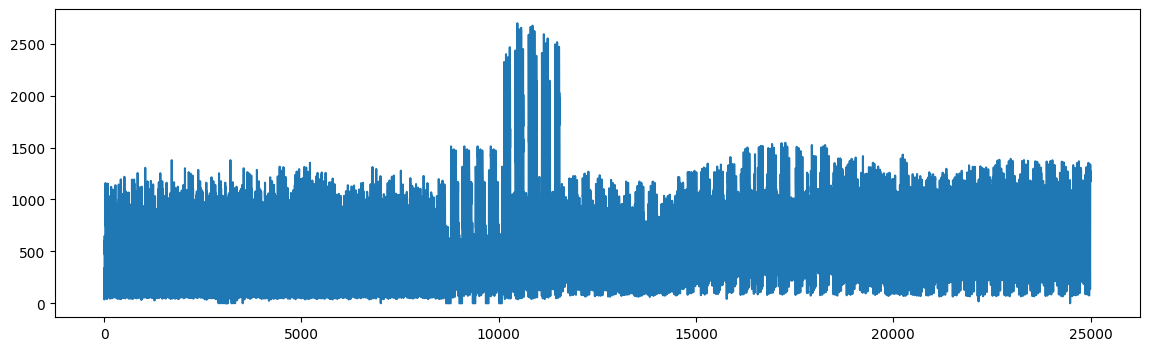

In [5]:
fig, ax = plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(madrid[:])
plt.show()

Самостоятельно реализуйте функцию, принимающую на вход многомерный временной ряд и возвращающий:
1. Все подпоследовательности временного ряда, в которых некоторые значения временного ряда были заменены nan значениями.
2. Индексы пропущенных значений
   
Процент пропущенных значений должен регулироваться отдельным параметром.


In [6]:
def add_nan(x, percent = 0.25):
    x_nan = copy.deepcopy(x)
    nan_len = x.shape[0] * percent
    nan_counter = 0

    for i in range(x_nan.shape[0]):
        if nan_counter <= nan_len and random.randint(0, 1):
            x_nan[i] = np.nan
            nan_counter += 1

    return x_nan, np.isnan(x_nan)

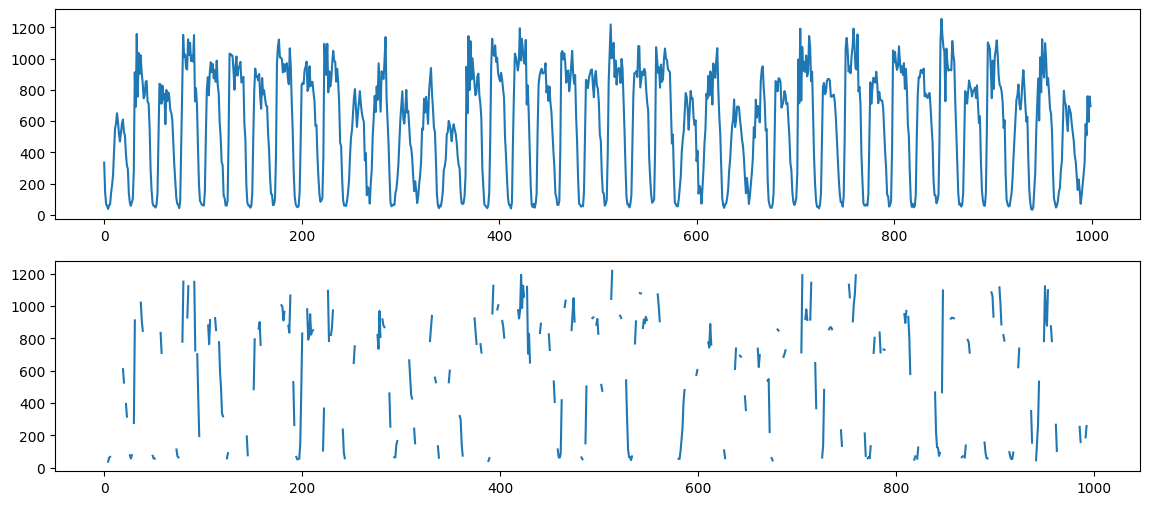

In [7]:
madrid_with_nan, index = add_nan(madrid)
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_with_nan[:1000])
plt.show()

In [8]:
recovery = {}

#### **7.1.2.** Заполнение существующими значениями ряда

In [9]:
madrid_mean = madrid_with_nan.copy()
madrid_mean[index] = np.nanmean(madrid_mean)
recovery['mean'] = madrid_mean

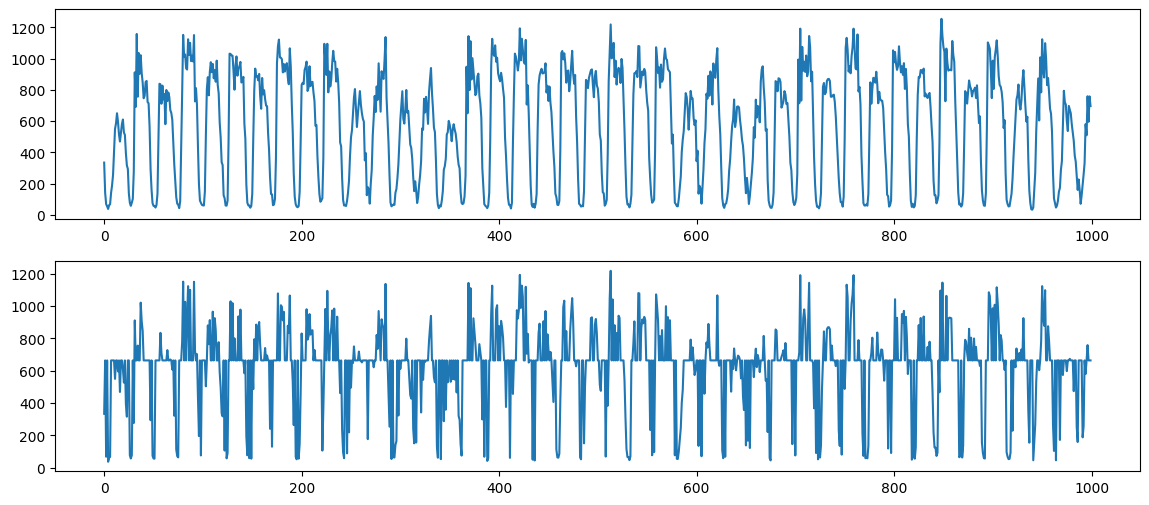

In [10]:
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_mean[:1000])
plt.show()

In [11]:
madrid_median = madrid_with_nan.copy()
madrid_median[index] = np.nanmedian(madrid_median)

In [12]:
recovery['median'] = madrid_median

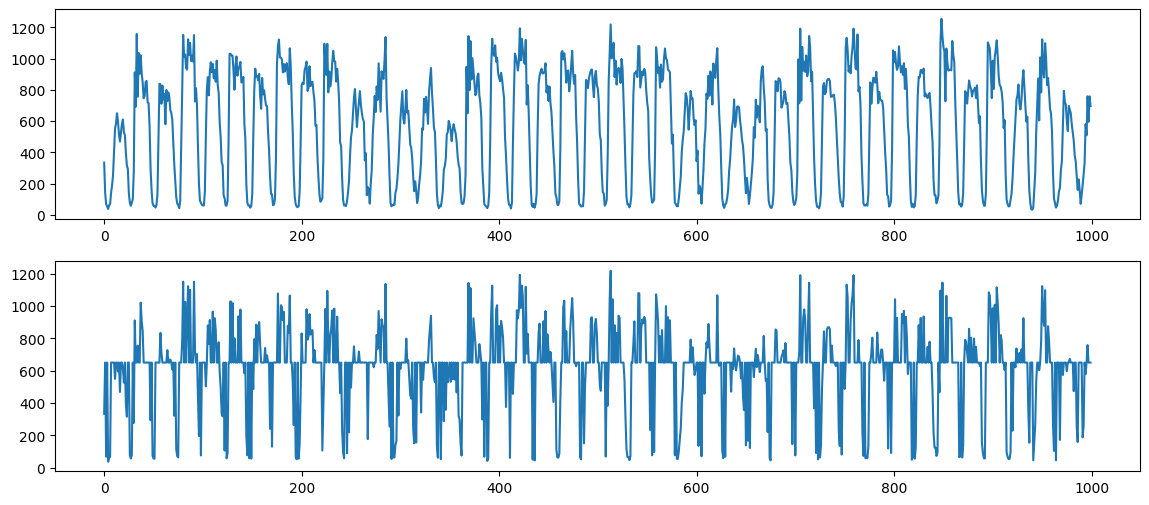

In [13]:
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_median[:1000])
plt.show()

Самостоятельно реализуйте один метод из первой группы ***табл. 7.1*** и проведите постановление данных, сохранив результаты восстановления.

In [14]:
def hot_deck(ts, index):
    hot_deck = ts.copy()

    found_right = False
    for i in range(len(hot_deck)):
        if not index[i]:
            continue

        for right_ix in range(i, len(hot_deck)):
            if not (index[right_ix]):
                next = hot_deck[right_ix]
                found_right = True
                break

        if (found_right):
            hot_deck[i] = next
        else:
            hot_deck[i] = hot_deck[i-1]

    return hot_deck

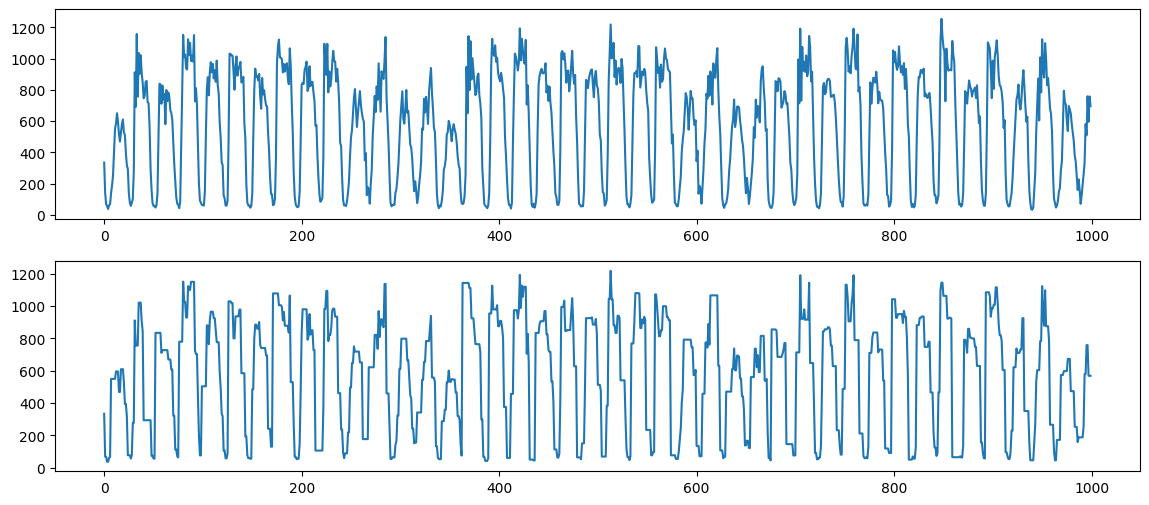

In [15]:
madrid_median = hot_deck(madrid_with_nan, index)
recovery['hot_deck'] = madrid_median

fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_median[:1000])

#### **7.1.3.** Заполнение на основе близких значений

Используя документацию одного из методов восстановления второй группы ***табл. 7.1*** и проведите восстановление данных, сохранив результаты восстановления.

In [16]:
def rolling_window(a, window, intersection=False):
    # result = torch.zeros(size=(a.shape[0],a.shape[1]))
    returns = []
    if intersection:  
        for i in range(0, a.shape[0]-window):
            returns.append(a[i:i + window])
    else:    
        for i in range(0, a.shape[0],window):
            returns.append(a[i:i + window])
    return np.stack(returns)


In [17]:
madrid_slice = rolling_window(madrid_with_nan, 100)

imputer = KNNImputer(n_neighbors=10)

madrid_knn = imputer.fit_transform(madrid_slice)
madrid_knn = madrid_knn.ravel()
recovery['knn'] = madrid_knn

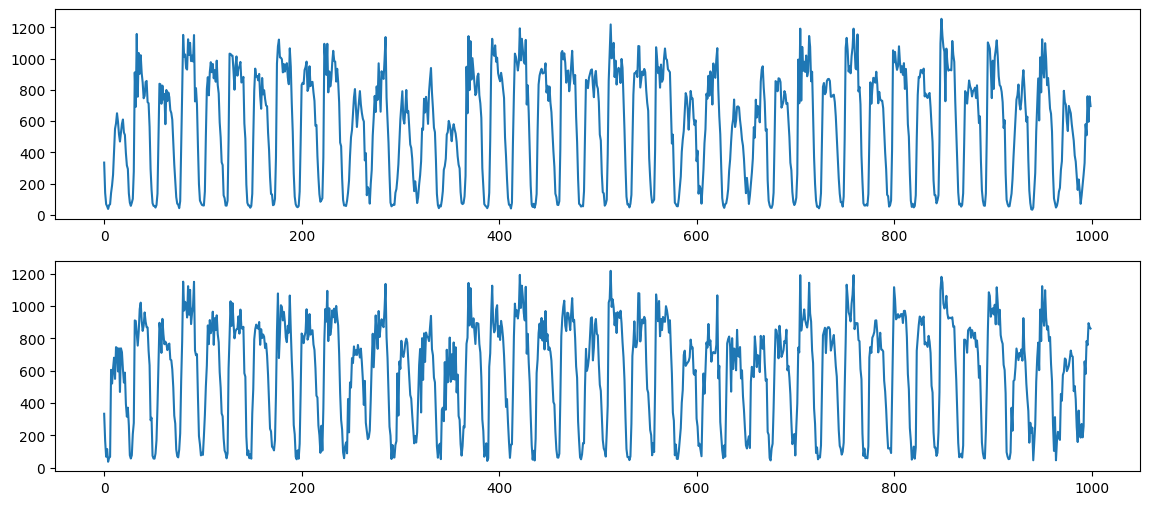

In [18]:
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_knn[:1000])

#### **7.1.4.** Заполнение на матричных преобразований

Используя документацию одного из методов восстановления третей группы ***табл. 7.1*** и проведите восстановление данных, сохранив результаты восстановления.

In [19]:
solver = IterativeSVD(rank=2)

madrid_iterative_svd = madrid_slice.copy()
madrid_iterative_svd = solver.fit_transform(madrid_iterative_svd)
madrid_iterative_svd = madrid_iterative_svd.ravel()
recovery['iterative_svd'] = madrid_iterative_svd

[IterativeSVD] Iter 1: observed MAE=345.827558
[IterativeSVD] Iter 2: observed MAE=269.801087
[IterativeSVD] Iter 3: observed MAE=260.293326
[IterativeSVD] Iter 4: observed MAE=257.764417
[IterativeSVD] Iter 5: observed MAE=257.036315
[IterativeSVD] Iter 6: observed MAE=256.809556
[IterativeSVD] Iter 7: observed MAE=256.738793
[IterativeSVD] Iter 8: observed MAE=256.719966
[IterativeSVD] Iter 9: observed MAE=256.714486
[IterativeSVD] Iter 10: observed MAE=256.713947


c:\Users\admin\Projects\labs\5\3\tsc\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\admin\Projects\labs\5\3\tsc\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\admin\Projects\labs\5\3\tsc\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


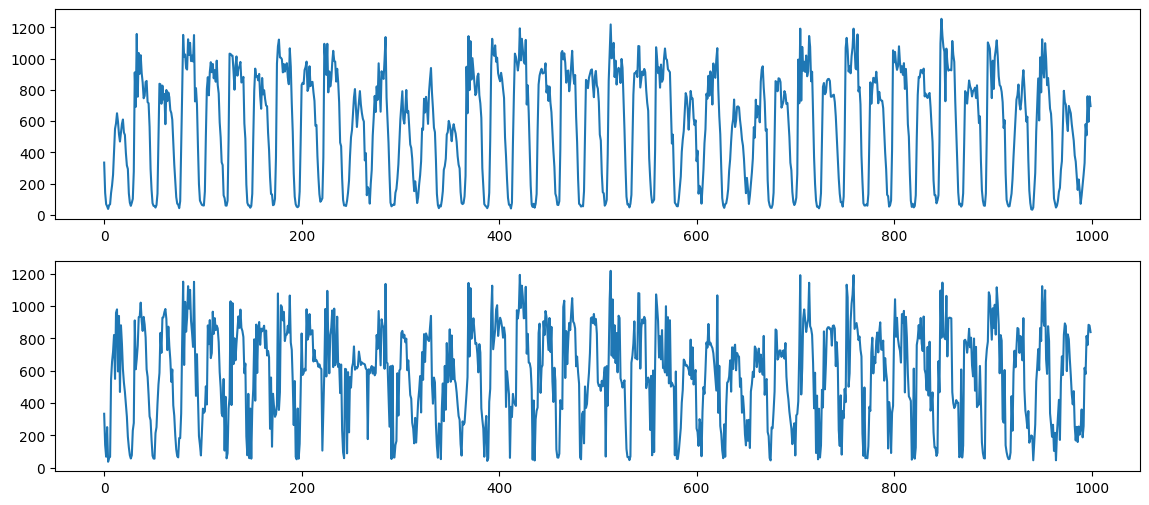

In [20]:
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_iterative_svd[:1000])

#### **7.1.5.** Сравнение результатов восстановления.

Для каждой группы методов постройте методов основные метрики оценки качества постановления.
На основе метрик отберите лучшие методы постановления метрик и выберите лучшую группу методов.
Для лучших методов из каждой группы постройте графики сравнения реальных и восстановленных данных. Объясните результаты и сделайте вывод.



In [21]:
methods = recovery.keys()

mean: 43373.523866933276
median: 42941.98784
hot_deck: 20495.83664
knn: 12832.4850508
iterative_svd: 29875.3816710363


Text(0, 0.5, 'MSE')

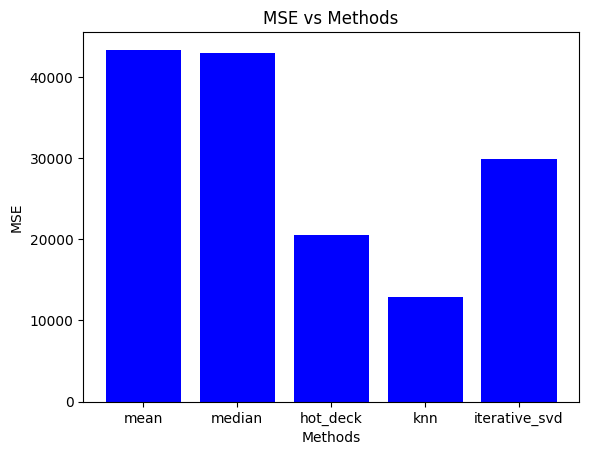

In [22]:
MSE = {}
for method in recovery:
    MSE[method] = mean_squared_error(madrid, recovery[method])
    print(f'{method}: {mean_squared_error(madrid, recovery[method])}')

plt.bar(methods, MSE.values(), color='blue')
plt.title('MSE vs Methods')
plt.xlabel('Methods')
plt.ylabel('MSE')

mean: 84.46331079844259
median: 84.06488
hot_deck: 44.25032
knn: 38.831052
iterative_svd: 68.62198135839009


Text(0, 0.5, 'MAE')

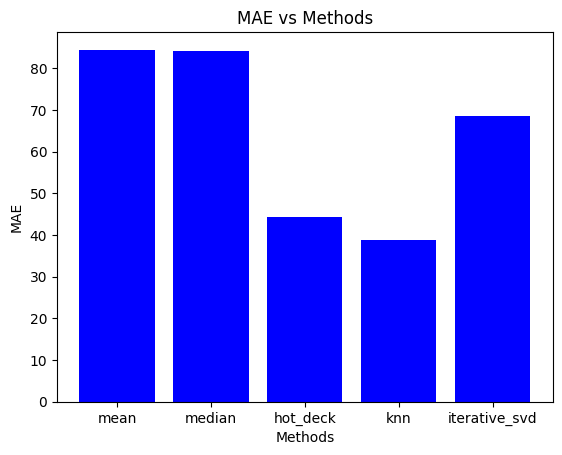

In [23]:
MAE = {}
for method in recovery:
    MAE[method] = mean_absolute_error(madrid, recovery[method])
    print(f'{method}: {mean_absolute_error(madrid, recovery[method])}')

plt.bar(methods, MAE.values(), color='blue')
plt.title('MAE vs Methods')
plt.xlabel('Methods')
plt.ylabel('MAE')

mean: 0.7224310465676818
median: 0.7251926622420661
hot_deck: 0.8688368521004193
knn: 0.9178784860456792
iterative_svd: 0.8088124347640899


Text(0, 0.5, 'R2')

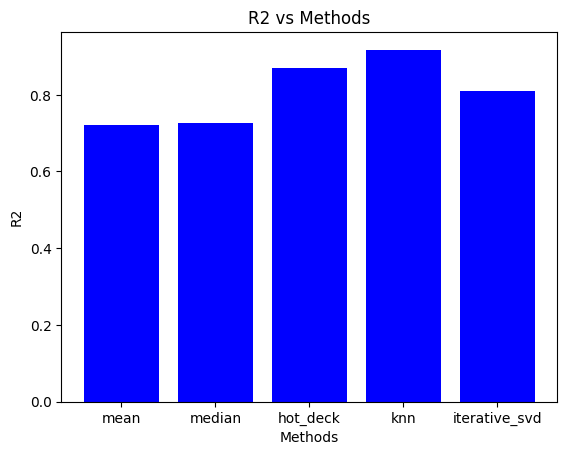

In [24]:
R2 = {}
for method in recovery:
    R2[method] = r2_score(madrid, recovery[method])
    print(f'{method}: {r2_score(madrid, recovery[method])}')

plt.bar(methods, R2.values(), color='blue')
plt.title('R2 vs Methods')
plt.xlabel('Methods')
plt.ylabel('R2')

**Выводы**: На всех метриках себя лучше всего показал методы KNN и Hot-Deck